# Programmes du programme de terminale

## Suites
### Somme des termes d'une suite
Déterminer $\displaystyle\sum_{k=1}^n\dfrac{k^2}{4^k}=\dfrac{1^2}{4^1}+\dfrac{2^2}{4^2}+\cdots+\dfrac{n^2}{4^n}$.

In [ ]:
def somme(n):
    S = 0
    for k in range(1, n + 1):
        S = S + k**2/4**k
    return S

somme(1000)

**Notation `+=`**

In [ ]:
def somme(n):
    S = 0
    for k in range(1, n + 1):
        S += k**2/4**k
    return S

somme(1000)

**Utilisation d'une boucle `while`**

In [ ]:
def somme(n):
    S = 0
    k = 1
    while k <= n:
        S += k**2 / 4**k
        k += 1
    return S

somme(1000)

## Dénombrement et probabilités
### Factorielles
Calculer $n!$ où $n$ est un entier naturel.

In [ ]:
def factorielle(n):
    resultat = 1
    for k in range(1, n + 1):
        resultat *= k
    return resultat

factorielle(6)

**Utilisation de `while`**

In [ ]:
def factorielle(n):
    resultat = 1
    k = 1
    while k < n:
        k += 1
        resultat *= k
    return resultat

factorielle(6)

**Utilisation de `while` (bis)**

In [ ]:
def factorielle(n):
    if n == 0:
        return 1
    resultat = n
    while n > 1:
        n -= 1
        resultat *= n
    return resultat

factorielle(6)

**Fonction récursive**

In [ ]:
def factorielle(n):
    if n == 0:
        return 1
    else:
        return n * factorielle(n - 1)

factorielle(6)

### Calcul des coefficients binomiaux
Déterminer $\displaystyle\binom{n}{k}$ où $k$ et $n$ sont des entiers naturels avec $k\leq n$.

In [ ]:
def binom(n, k):
    if n == 0 or k == 0 or n == k:
        return 1
    if k > n//2:
        k = n - k
    resultat = n
    for i in range(2, k+1):
        resultat *= n - i + 1
        resultat //= i
    return resultat

binom(7, 3)

### Formule de Pascal
Déterminer $\displaystyle\binom{n}{k}$ en utilisant la formule de Pascal.

In [ ]:
def binom(n, k):
    if k == 0 or k == n:
        return 1
    else:
        return binom(n - 1, k - 1) + binom(n - 1, k)

binom(7, 3)

### Triangle de Pascal
Soit $n$ un entier naturel. Donner sous forme de liste la ligne $n$ du triangle de Pascal.

In [ ]:
def triangle_pascal(n):
    if n == 0:
        return [1]
    ligne = triangle_pascal(n - 1)
    ligne_suivante = [1]
    for i in range(n - 1):
        ligne_suivante.append(ligne[i] + ligne[i + 1])
    ligne_suivante.append(1)
    return ligne_suivante

triangle_pascal(5)

### Permutations des éléments d'une liste
Déterminer toutes les permutations des éléments de `["A", "B", "C"]`

In [ ]:
def permutations(liste):
    if len(liste) <= 1:
        return [liste]

    resultat = []
    
    for x in liste:
        sous_liste = liste.copy()
        sous_liste.remove(x)
        for p in permutations(sous_liste):
            resultat.append([x] + p)
    return resultat

permutations(["A", "B", "C"])

**Remarque**

Des fonctions prédéfinies permettent d'obtenir les permutations, arrangements et combinaisons directement (applicable sur des listes, des ensembles, ...).

In [ ]:
from itertools import permutations, combinations

print(list(permutations(["A", "B", "C"])))
print(list(permutations(["A", "B", "C"], 2)))
print(list(combinations(["A", "B", "C"], 2)))

### Simulation d'une loi binomiale
Simuler la répétition de $n$ épreuves de Bernoulli identiques et indépendantes de paramètre $p$. Compter le nombre de succès

In [ ]:
from random import random

def succes_n_epreuves_bernoulli(n, p):
    succes = 0
    for i in range(n):
        if random() < p:
            succes += 1
    return succes

succes_n_epreuves_bernoulli(100, 0.3)

In [ ]:
def loi_binomiale(n, p, nombre_de_simulations):
    loi_simulee = [0 for _ in range(n + 1)]
    for _ in range(nombre_de_simulations):
        k = succes_n_epreuves_bernoulli(n, p)
        loi_simulee[k] += 1
    return [x / nombre_de_simulations for x in loi_simulee]

loi_binomiale(10, 0.3, 10000)

In [ ]:
from scipy.stats import binom

n = 10
p = 0.3

valeurs = list(range(n + 1))
probabilites = binom.pmf(valeurs, n, p)

print(probabilites)

### Marche aléatoire
Simuler et représenter une marche aléatoire en une dimension $\{-1,+1\}$ avec une probabilité $p$ de $+1$.

In [ ]:
from random import random

def marche_aleatoire(n, p):
    position = 0
    marche = [position]
    for _ in range(n):
        if random() < p:
            position += 1
        else:
            position -= 1
        marche.append(position)
    return marche

marche_aleatoire(20, 0.5)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(marche_aleatoire(200, 0.5))
plt.title("Marche aléatoire")
plt.xlabel("Nombre de pas")
plt.ylabel("Position")
plt.show()

## Intégrales
### Méthode des rectangles à gauche
Soit $f$ une fonction continue sur un intervalle $[a,b]$. Déterminer une valeur approchée de $\displaystyle\int_a^bf(x)\,\text{d}x$ par la méthode des rectangles à gauche.

In [ ]:
def integrale_rect_gauche(f, a, b, n):
    h = (b - a) / n
    somme = 0
    for k in range(n):
        somme += f(a + k * h)
    return somme * h

def f(x):
    return x**2

integrale_rect_gauche(f, 0, 2, 1000)

Dans le cas de cet exemple, la valeur théorique est de $\dfrac{8}{3}\approx2,666666666666667$.

### Méthode des rectangles (point du milieu)

In [ ]:
def integrale_rect_milieu(f, a, b, n):
    h = (b - a) / n
    somme = 0
    for k in range(n):
        somme += f(a + (k + 0.5) * h)
    return somme * h

def f(x):
    return x**2

integrale_rect_milieu(f, 0, 2, 1000)

### Méthode de Monte-Carlo
On suppose ici que pour tout $x$ de $[a,b]$ : $$0\leq f(x)\leq Max$$

In [ ]:
from random import random

def integrale_monte_carlo(f, a, b, Max, n):
    nb_points = 0
    for _ in range(n):
        x = random() * (b - a) + a
        y = random() * Max
        if y <= f(x):
            nb_points += 1
    return Max * (b - a) * nb_points / n 

integrale_monte_carlo(f, 0, 2, 4, 10000)

### Valeur approchée de $\pi$ par la méthode de Monte-Carlo

In [ ]:
from random import random

def pi_Monte_Carlo(n):
    nb_points = 0
    for _ in range(n):
        x = random()
        y = random()
        if x**2 + y**2 <= 1:
            nb_points += 1
    return 4 * nb_points / n

pi_Monte_Carlo(10000)

**Représentation graphique**

In [ ]:
import matplotlib.pyplot as plt
from random import random
from math import pi

fig, ax = plt.subplots()

def pi_Monte_Carlo_graph(n):
    nb_points = 0
    x_in = []
    y_in = []
    x_out = []
    y_out = []
    for k in range(n):
        x = random()
        y = random()
        if x**2 + y**2 <= 1:
            nb_points += 1
            x_in.append(x)
            y_in.append(y)
        else:
            x_out.append(x)
            y_out.append(y)
    ax.scatter(x_in, y_in, color='red', s=1)
    ax.scatter(x_out, y_out, color='#a1ff97', s=1)
    ax.set_aspect("equal")

    plt.title(rf"""Approximation de $\pi$ par la méthode de Monte Carlo
    Nombre de points : {n} - Valeur : {4 * nb_points / n} - Erreur relative : {abs(4 * nb_points / n - pi)/pi:.2%}""")

pi_Monte_Carlo_graph(10000)
plt.show()

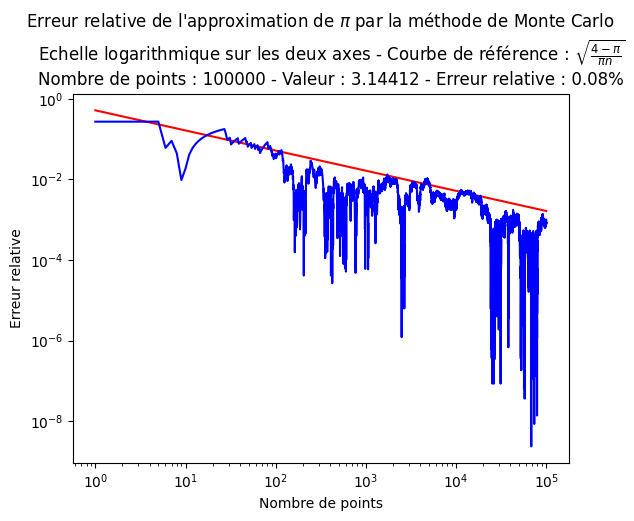

In [39]:
from random import random
from math import pi
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

def pi_Monte_Carlo(n):
    nb_points = 0
    n_list = []
    erreur_list = []
    for k in range(n):
        x = random()
        y = random()
        if x**2 + y**2 <= 1:
            nb_points += 1
        n_list.append(k + 1)
        erreur_list.append(abs(4 * nb_points / (k + 1) - pi)/pi)
    ref_list = [((4 - pi) / (pi * (k + 1)))**0.5 for k in range(n)]
    ax.plot(n_list, ref_list, color='red')
    ax.plot(n_list, erreur_list, color='blue')
    ax.set_xscale("log")
    ax.set_yscale("log")
    plt.title(rf"""Erreur relative de l'approximation de $\pi$ par la méthode de Monte Carlo
    Echelle logarithmique sur les deux axes - Courbe de référence : $\sqrt{{\frac{{4-\pi}}{{\pi n}}}}$
    Nombre de points : {n} - Valeur : {4 * nb_points / n} - Erreur relative : {abs(4 * nb_points / n - pi)/pi:.2%}""")
    plt.xlabel("Nombre de points")
    plt.ylabel("Erreur relative")


pi_Monte_Carlo(100000)

## Equations
### Méthode de Newton
Soit $f$ une fonction définie et dérivable sur un intervalle $[a,b]$. On suppose que :
- l'équation $f(x)=0$ admet une unique solution sur $[a,b]$ ;
- $f'(x)\neq0$ sur $[a,b]$.
Déterminer une valeur approchée de la solution de l'équation $f(x)=0$ par la méthode de Newton (en supposant qu'elle converge).

In [ ]:
def newton(f, f_p, x0, max_iter=100, tol=1e-7):
    x = x0
    for _ in range(max_iter):
        x_new = x - f(x) / f_p(x)
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

def f(x):
    return x**3 + x - 1

def f_p(x):
    return 3*x**2 + 1

newton(f, f_p, 0.5)